In [ ]:
# 결측치나 이상치, 문자열 등 없는지 확인하기 위해

import pandas as pd
import numpy as np

hitter = pd.read_csv("../data/hitter_training.csv")
pitcher = pd.read_csv("../data/pitcher_training.csv")

print("타자 데이터:", hitter.shape)
print("투수 데이터:", pitcher.shape)

display(hitter.head())
display(pitcher.head())

타자 데이터: (47, 7)
투수 데이터: (30, 7)


,player_name,fa_year,war_3yr_avg,ops_3yr_avg,wrc_plus_3yr_avg,games_3yr_avg,annual_avg_salary
0,이대호,2021,3.556667,0.861000,107.466667,141.000000,13.00
1,김재호,2021,2.630000,0.771667,121.000000,127.000000,8.33
2,이원석,2021,1.630000,0.794333,90.833333,120.000000,6.67
3,정수빈,2021,2.260000,0.782333,123.966667,96.666667,9.33
4,최형우,2021,5.796667,0.961333,149.966667,139.666667,15.67


,player_name,fa_year,war_3yr_avg,era_3yr_avg,innings_3yr_avg,games_3yr_avg,annual_avg_salary
0,이용찬,2021,2.205,3.847585,146.166667,25.500000,6.75
1,유희관,2021,0.710,4.988577,147.888889,28.000000,10.00
2,차우찬,2021,-0.080,5.102535,169.166667,29.000000,10.00
3,우규민,2021,1.090,4.409570,55.222222,51.333333,5.00
4,백정현,2022,3.275,3.433915,157.333333,27.500000,9.50


In [2]:
# 머신러닝은 NaN 싫어함. 특히 Linear Regression은 NaN이 있으면 학습이 안됨. 따라서 결측치 확인 필요

print("\n===== 타자 결측치 =====")
print(hitter.isnull().sum())

print("\n===== 투수 결측치 =====")
print(pitcher.isnull().sum())


===== 타자 결측치 =====
player_name          0
fa_year              0
war_3yr_avg          0
ops_3yr_avg          0
wrc_plus_3yr_avg     0
games_3yr_avg        0
annual_avg_salary    0
dtype: int64

===== 투수 결측치 =====
player_name          0
fa_year              0
war_3yr_avg          0
era_3yr_avg          0
innings_3yr_avg      0
games_3yr_avg        0
annual_avg_salary    0
dtype: int64


In [3]:
# 이상치 확인(예를 들어 OPS 9.5 등과 같은 값 나오면 데이터 이상)
print(hitter.describe())

print(pitcher.describe())

           fa_year  war_3yr_avg  ops_3yr_avg  wrc_plus_3yr_avg  games_3yr_avg  \
count    47.000000    47.000000    47.000000         47.000000      47.000000   
mean   2023.021277     2.830426     0.782812        113.589007     122.269504   
std       1.700248     1.528436     0.089080         23.557849      14.051473   
min    2021.000000     0.003333     0.592000         69.733333      85.500000   
25%    2022.000000     1.883333     0.717250         94.208333     116.666667   
50%    2023.000000     2.716667     0.782333        115.000000     126.000000   
75%    2024.500000     3.868333     0.829833        126.283333     133.166667   
max    2026.000000     5.796667     0.972667        156.033333     141.000000   

       annual_avg_salary  
count          47.000000  
mean           12.757872  
std             6.904178  
min             1.000000  
25%             8.665000  
50%            12.500000  
75%            16.460000  
max            28.750000  
           fa_year  war_3yr

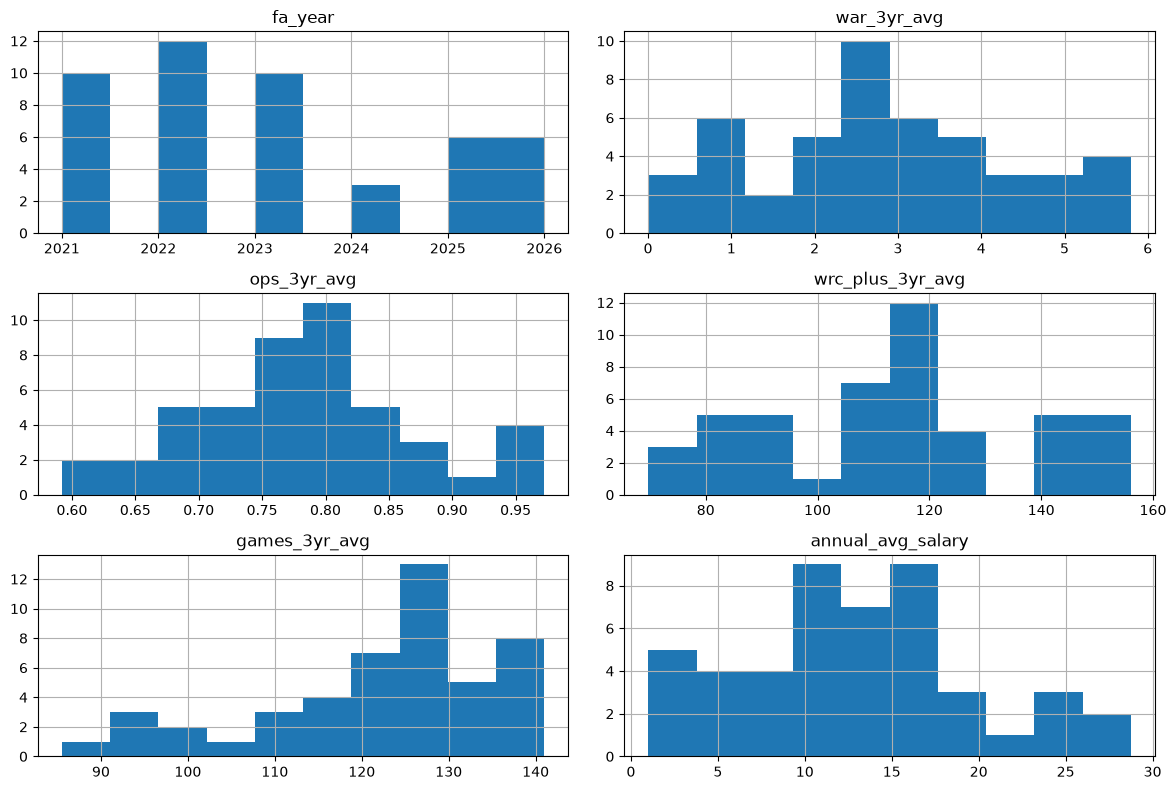

In [4]:
# 보고서 EDA에 바로 들어감
import matplotlib.pyplot as plt

hitter.hist(
    figsize=(12,8)
)

plt.tight_layout()
plt.show()

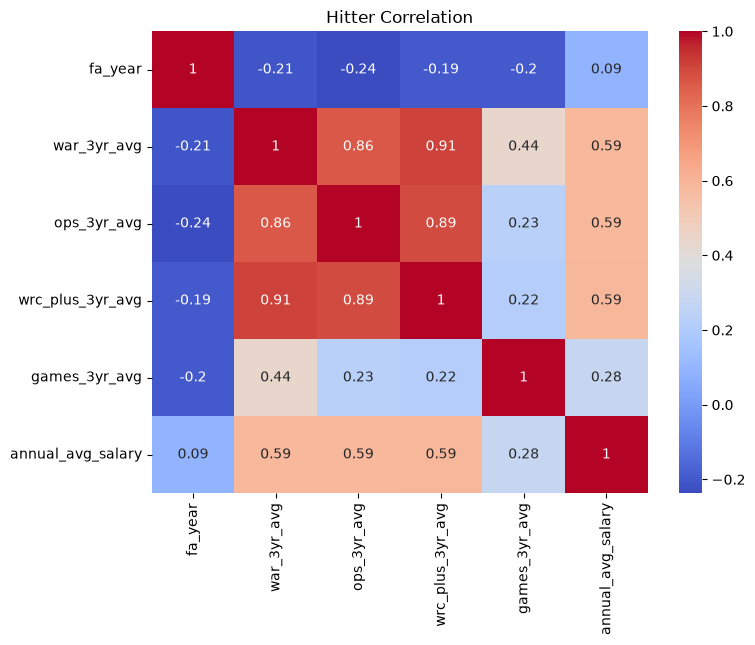

In [6]:
# 우리가 알고싶은 WAR상승 시 연봉 상승?, OPS상승 시 연봉 상승? 등등의 상관관계 확인 가능
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    hitter.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Hitter Correlation")

plt.show()

In [9]:
import pandas as pd
import numpy as np

# 원천 데이터
hitter = pd.read_csv("../data/hitter_season_stats_2018_2026.csv")
pitcher = pd.read_csv("../data/pitcher_season_stats_2018_2026.csv")

# FA 데이터
fa = pd.read_csv("../data/fa_contracts.csv")

# 타자/투수 구분
fa["position_group"] = fa["position"].apply(
    lambda x: "pitcher" if x == "P" else "hitter"
)

print("타자:", hitter.shape)
print("투수:", pitcher.shape)
print("FA:", fa.shape)

display(fa.head())

타자: (1003, 27)
투수: (1452, 17)
FA: (89, 9)


,player_name,fa_year,age_at_fa,position,contract_years,total_contract_amount,annual_avg_salary,team,position_group
0,이용찬,2021,NaN,P,4,27.0,6.75,NC,pitcher
1,유희관,2021,NaN,P,1,10.0,10.00,두산,pitcher
2,차우찬,2021,NaN,P,2,20.0,10.00,LG,pitcher
3,이대호,2021,NaN,1B,2,26.0,13.00,롯데,hitter
4,김상수,2021,NaN,P,3,15.5,5.17,SK,pitcher


In [10]:
import pandas as pd
import numpy as np

# 혹시 문자열 숫자가 섞여 있을 수 있으므로 숫자형 변환
hitter_numeric_cols = [
    "hitterGameCount", "hitterAb",
    "hitterHra", "hitterObp", "hitterSlg", "hitterOps",
    "hitterWrcPlus", "hitterHr", "hitterRbi", "hitterRun",
    "hitterHit", "hitterH2", "hitterH3",
    "hitterBb", "hitterKk", "hitterSb", "hitterCs",
    "hitterGd", "hitterWpa", "hitterWar"
]

for col in hitter_numeric_cols:
    if col in hitter.columns:
        hitter[col] = pd.to_numeric(hitter[col], errors="coerce")

fa_hitter = fa[fa["position_group"] == "hitter"].copy()

hitter_rows = []

for _, row in fa_hitter.iterrows():
    player = row["player_name"]
    fa_year = int(row["fa_year"])
    target_years = [fa_year - 3, fa_year - 2, fa_year - 1]

    stats = hitter[
        (hitter["playerName"] == player) &
        (hitter["collect_year"].isin(target_years))
    ]

    # 최소 2년치 이상 있어야 사용
    if len(stats) < 2:
        continue

    hitter_rows.append({
        "player_name": player,
        "fa_year": fa_year,
        "age_at_fa": row["age_at_fa"],
        "position": row["position"],

        # 기본/출장
        "games_3yr_avg": stats["hitterGameCount"].mean(),
        "ab_3yr_avg": stats["hitterAb"].mean(),

        # 공격 지표
        "avg_3yr_avg": stats["hitterHra"].mean(),
        "obp_3yr_avg": stats["hitterObp"].mean(),
        "slg_3yr_avg": stats["hitterSlg"].mean(),
        "ops_3yr_avg": stats["hitterOps"].mean(),
        "wrc_plus_3yr_avg": stats["hitterWrcPlus"].mean(),

        # 누적형 타격 지표
        "hr_3yr_avg": stats["hitterHr"].mean(),
        "rbi_3yr_avg": stats["hitterRbi"].mean(),
        "run_3yr_avg": stats["hitterRun"].mean(),
        "hit_3yr_avg": stats["hitterHit"].mean(),
        "double_3yr_avg": stats["hitterH2"].mean(),
        "triple_3yr_avg": stats["hitterH3"].mean(),

        # 선구안/삼진
        "bb_3yr_avg": stats["hitterBb"].mean(),
        "kk_3yr_avg": stats["hitterKk"].mean(),

        # 주루/기타
        "sb_3yr_avg": stats["hitterSb"].mean(),
        "cs_3yr_avg": stats["hitterCs"].mean(),
        "gd_3yr_avg": stats["hitterGd"].mean(),

        # 종합 기여도
        "wpa_3yr_avg": stats["hitterWpa"].mean(),
        "war_3yr_avg": stats["hitterWar"].mean(),
        "war_3yr_sum": stats["hitterWar"].sum(),

        # 정답값
        "contract_years": row["contract_years"],
        "total_contract_amount": row["total_contract_amount"],
        "annual_avg_salary": row["annual_avg_salary"],
        "team": row["team"]
    })

hitter_training_v2 = pd.DataFrame(hitter_rows)

print("타자 학습 데이터 v2:", hitter_training_v2.shape)
display(hitter_training_v2.head())

hitter_training_v2.to_csv(
    "../data/hitter_training_v2.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료: ../data/hitter_training_v2.csv")

타자 학습 데이터 v2: (47, 29)


,player_name,fa_year,age_at_fa,position,games_3yr_avg,ab_3yr_avg,avg_3yr_avg,obp_3yr_avg,slg_3yr_avg,ops_3yr_avg,...,sb_3yr_avg,cs_3yr_avg,gd_3yr_avg,wpa_3yr_avg,war_3yr_avg,war_3yr_sum,contract_years,total_contract_amount,annual_avg_salary,team
0,이대호,2021,NaN,1B,141.000000,523.333333,0.303127,0.367667,0.493333,0.861000,...,0.333333,NaN,NaN,1.127000,3.556667,10.67,2,26.0,13.00,롯데
1,김재호,2021,NaN,SS,127.000000,393.666667,0.289136,0.377000,0.394667,0.771667,...,5.000000,NaN,NaN,-0.487667,2.630000,7.89,3,25.0,8.33,두산
2,이원석,2021,NaN,3B,120.000000,425.666667,0.271395,0.347333,0.447000,0.794333,...,1.333333,NaN,NaN,0.501333,1.630000,4.89,3,20.0,6.67,삼성
3,정수빈,2021,NaN,OF,96.666667,343.000000,0.310204,0.383667,0.398667,0.782333,...,15.333333,NaN,NaN,-0.551000,2.260000,6.78,6,56.0,9.33,두산
4,최형우,2021,NaN,OF,139.666667,502.000000,0.331287,0.420000,0.541333,0.961333,...,1.000000,NaN,NaN,3.712667,5.796667,17.39,3,47.0,15.67,KIA


저장 완료: ../data/hitter_training_v2.csv


In [13]:
def convert_inning(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if " " in value:
        whole, fraction = value.split(" ")
        numerator, denominator = fraction.split("/")
        return float(whole) + float(numerator) / float(denominator)

    if "/" in value:
        numerator, denominator = value.split("/")
        return float(numerator) / float(denominator)

    return float(value)


pitcher_feature_map = {
    "pitcherGameCount": "games_3yr_avg",
    "pitcherInning": "innings_3yr_avg",
    "pitcherEra": "era_3yr_avg",
    "pitcherWhip": "whip_3yr_avg",
    "pitcherWin": "win_3yr_avg",
    "pitcherLose": "lose_3yr_avg",
    "pitcherSave": "save_3yr_avg",
    "pitcherHold": "hold_3yr_avg",
    "pitcherHit": "hit_allowed_3yr_avg",
    "pitcherWar": "war_3yr_avg"
}

for raw_col in pitcher_feature_map.keys():
    if raw_col == "pitcherInning":
        pitcher[raw_col] = pitcher[raw_col].apply(convert_inning)
    else:
        pitcher[raw_col] = pd.to_numeric(pitcher[raw_col], errors="coerce")

fa_pitcher = fa[fa["position_group"] == "pitcher"].copy()

pitcher_rows = []

for _, row in fa_pitcher.iterrows():
    player = row["player_name"]
    fa_year = int(row["fa_year"])
    target_years = [fa_year - 3, fa_year - 2, fa_year - 1]

    stats = pitcher[
        (pitcher["playerName"] == player) &
        (pitcher["collect_year"].isin(target_years))
    ]

    if len(stats) < 2:
        continue

    result = {
        "player_name": player,
        "fa_year": fa_year,
        "age_at_fa": row["age_at_fa"],
        "position": row["position"],

        "contract_years": row["contract_years"],
        "total_contract_amount": row["total_contract_amount"],
        "annual_avg_salary": row["annual_avg_salary"],
        "team": row["team"]
    }

    for raw_col, new_col in pitcher_feature_map.items():
        result[new_col] = stats[raw_col].mean()

    result["war_3yr_sum"] = stats["pitcherWar"].sum()

    pitcher_rows.append(result)

pitcher_training_v2 = pd.DataFrame(pitcher_rows)

print("투수 학습 데이터 v2:", pitcher_training_v2.shape)
display(pitcher_training_v2.head())

pitcher_training_v2.to_csv(
    "../data/pitcher_training_v2.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료: ../data/pitcher_training_v2.csv")

투수 학습 데이터 v2: (30, 19)


,player_name,fa_year,age_at_fa,position,contract_years,total_contract_amount,annual_avg_salary,team,games_3yr_avg,innings_3yr_avg,era_3yr_avg,whip_3yr_avg,win_3yr_avg,lose_3yr_avg,save_3yr_avg,hold_3yr_avg,hit_allowed_3yr_avg,war_3yr_avg,war_3yr_sum
0,이용찬,2021,NaN,P,4,27.0,6.75,NC,25.500000,146.166667,3.847585,1.370000,11.000000,6.500000,0.000000,0.000000,159.5,2.205,4.41
1,유희관,2021,NaN,P,1,10.0,10.00,두산,28.000000,147.888889,4.988577,1.553333,10.333333,9.666667,0.000000,0.000000,186.0,0.710,2.13
2,차우찬,2021,NaN,P,2,20.0,10.00,LG,29.000000,169.166667,5.102535,1.470000,12.500000,9.000000,0.000000,0.000000,179.0,-0.080,-0.16
3,우규민,2021,NaN,P,2,10.0,5.00,삼성,51.333333,55.222222,4.409570,1.336667,3.000000,3.666667,7.333333,9.333333,63.0,1.090,3.27
4,백정현,2022,NaN,P,4,38.0,9.50,삼성,27.500000,157.333333,3.433915,1.300000,11.000000,7.500000,0.000000,0.000000,150.0,3.275,6.55


저장 완료: ../data/pitcher_training_v2.csv


In [14]:
import pandas as pd
import numpy as np

hitter_v2 = pd.read_csv("../data/hitter_training_v2.csv")
pitcher_v2 = pd.read_csv("../data/pitcher_training_v2.csv")

print("타자 v2:", hitter_v2.shape)
print("투수 v2:", pitcher_v2.shape)

display(hitter_v2.head())
display(pitcher_v2.head())

타자 v2: (47, 29)
투수 v2: (30, 19)


,player_name,fa_year,age_at_fa,position,games_3yr_avg,ab_3yr_avg,avg_3yr_avg,obp_3yr_avg,slg_3yr_avg,ops_3yr_avg,...,sb_3yr_avg,cs_3yr_avg,gd_3yr_avg,wpa_3yr_avg,war_3yr_avg,war_3yr_sum,contract_years,total_contract_amount,annual_avg_salary,team
0,이대호,2021,NaN,1B,141.000000,523.333333,0.303127,0.367667,0.493333,0.861000,...,0.333333,NaN,NaN,1.127000,3.556667,10.67,2,26.0,13.00,롯데
1,김재호,2021,NaN,SS,127.000000,393.666667,0.289136,0.377000,0.394667,0.771667,...,5.000000,NaN,NaN,-0.487667,2.630000,7.89,3,25.0,8.33,두산
2,이원석,2021,NaN,3B,120.000000,425.666667,0.271395,0.347333,0.447000,0.794333,...,1.333333,NaN,NaN,0.501333,1.630000,4.89,3,20.0,6.67,삼성
3,정수빈,2021,NaN,OF,96.666667,343.000000,0.310204,0.383667,0.398667,0.782333,...,15.333333,NaN,NaN,-0.551000,2.260000,6.78,6,56.0,9.33,두산
4,최형우,2021,NaN,OF,139.666667,502.000000,0.331287,0.420000,0.541333,0.961333,...,1.000000,NaN,NaN,3.712667,5.796667,17.39,3,47.0,15.67,KIA


,player_name,fa_year,age_at_fa,position,contract_years,total_contract_amount,annual_avg_salary,team,games_3yr_avg,innings_3yr_avg,era_3yr_avg,whip_3yr_avg,win_3yr_avg,lose_3yr_avg,save_3yr_avg,hold_3yr_avg,hit_allowed_3yr_avg,war_3yr_avg,war_3yr_sum
0,이용찬,2021,NaN,P,4,27.0,6.75,NC,25.500000,146.166667,3.847585,1.370000,11.000000,6.500000,0.000000,0.000000,159.5,2.205,4.41
1,유희관,2021,NaN,P,1,10.0,10.00,두산,28.000000,147.888889,4.988577,1.553333,10.333333,9.666667,0.000000,0.000000,186.0,0.710,2.13
2,차우찬,2021,NaN,P,2,20.0,10.00,LG,29.000000,169.166667,5.102535,1.470000,12.500000,9.000000,0.000000,0.000000,179.0,-0.080,-0.16
3,우규민,2021,NaN,P,2,10.0,5.00,삼성,51.333333,55.222222,4.409570,1.336667,3.000000,3.666667,7.333333,9.333333,63.0,1.090,3.27
4,백정현,2022,NaN,P,4,38.0,9.50,삼성,27.500000,157.333333,3.433915,1.300000,11.000000,7.500000,0.000000,0.000000,150.0,3.275,6.55


In [15]:
print("===== 타자 결측치 =====")
print(hitter_v2.isnull().sum())

print("\n===== 투수 결측치 =====")
print(pitcher_v2.isnull().sum())

===== 타자 결측치 =====
player_name               0
fa_year                   0
age_at_fa                47
position                  0
games_3yr_avg             0
ab_3yr_avg                0
avg_3yr_avg               0
obp_3yr_avg               0
slg_3yr_avg               0
ops_3yr_avg               0
wrc_plus_3yr_avg          0
hr_3yr_avg                0
rbi_3yr_avg               0
run_3yr_avg               0
hit_3yr_avg               0
double_3yr_avg            0
triple_3yr_avg            0
bb_3yr_avg                0
kk_3yr_avg                0
sb_3yr_avg                0
cs_3yr_avg               47
gd_3yr_avg               47
wpa_3yr_avg               0
war_3yr_avg               0
war_3yr_sum               0
contract_years            0
total_contract_amount     0
annual_avg_salary         0
team                      0
dtype: int64

===== 투수 결측치 =====
player_name               0
fa_year                   0
age_at_fa                30
position                  0
contract_years          

In [16]:
hitter_features = [
    "games_3yr_avg",
    "ab_3yr_avg",
    "avg_3yr_avg",
    "obp_3yr_avg",
    "slg_3yr_avg",
    "ops_3yr_avg",
    "wrc_plus_3yr_avg",
    "hr_3yr_avg",
    "rbi_3yr_avg",
    "run_3yr_avg",
    "hit_3yr_avg",
    "bb_3yr_avg",
    "kk_3yr_avg",
    "sb_3yr_avg",
    "cs_3yr_avg",
    "wpa_3yr_avg",
    "war_3yr_avg",
    "war_3yr_sum"
]

hitter_target = "annual_avg_salary"

In [17]:
pitcher_features = [
    "games_3yr_avg",
    "innings_3yr_avg",
    "era_3yr_avg",
    "whip_3yr_avg",
    "win_3yr_avg",
    "lose_3yr_avg",
    "save_3yr_avg",
    "hold_3yr_avg",
    "hit_allowed_3yr_avg",
    "war_3yr_avg",
    "war_3yr_sum"
]

pitcher_target = "annual_avg_salary"

In [18]:
# 모델에 필요한 컬럼만 추출
hitter_model_df = hitter_v2[hitter_features + [hitter_target]].copy()
pitcher_model_df = pitcher_v2[pitcher_features + [pitcher_target]].copy()

# 숫자형 변환
for col in hitter_model_df.columns:
    hitter_model_df[col] = pd.to_numeric(hitter_model_df[col], errors="coerce")

for col in pitcher_model_df.columns:
    pitcher_model_df[col] = pd.to_numeric(pitcher_model_df[col], errors="coerce")

# 결측치가 있는 행 제거
hitter_model_df = hitter_model_df.dropna()
pitcher_model_df = pitcher_model_df.dropna()

print("타자 모델 데이터:", hitter_model_df.shape)
print("투수 모델 데이터:", pitcher_model_df.shape)

타자 모델 데이터: (0, 19)
투수 모델 데이터: (30, 12)


In [19]:
print(hitter_model_df.isnull().sum())

games_3yr_avg        0
ab_3yr_avg           0
avg_3yr_avg          0
obp_3yr_avg          0
slg_3yr_avg          0
ops_3yr_avg          0
wrc_plus_3yr_avg     0
hr_3yr_avg           0
rbi_3yr_avg          0
run_3yr_avg          0
hit_3yr_avg          0
bb_3yr_avg           0
kk_3yr_avg           0
sb_3yr_avg           0
cs_3yr_avg           0
wpa_3yr_avg          0
war_3yr_avg          0
war_3yr_sum          0
annual_avg_salary    0
dtype: int64


In [20]:
fa = pd.read_csv("../data/fa_contracts.csv")

players = (
    fa["player_name"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print(f"총 선수 수: {len(players)}")

for p in players:
    print(p)

총 선수 수: 83
강민호
강백호
강한울
고종욱
구승민
김강률
김광현
김대우
김민식
김상수
김선빈
김성욱
김성현
김용의
김원중
김재호
김재환
김진성
김헌곤
김현수
나성범
노경은
노진혁
류지혁
박건우
박동원
박민우
박병호
박세혁
박찬호
박해민
백정현
서건창
손아섭
신본기
심우준
양석환
양의지
양현종
엄상백
오선진
오승환
오재일
오지환
오태곤
우규민
원종현
유강남
유희관
이대호
이명기
이영하
이용찬
이원석
이재학
이준영
이태양
임기영
임찬규
임창민
장민재
장성우
장시환
장현식
정수빈
정훈
조수행
주권
차우찬
채은성
최원준
최원태
최재훈
최정
최주환
최형우
한승택
한현희
함덕주
허경민
허도환
홍건희
황재균


In [25]:
birth = pd.read_csv("../data/birth_year.csv")
fa = pd.read_csv("../data/fa_contracts.csv")

birth = birth.rename(
    columns={
        "name": "player_name"
    }
)

fa = fa.merge(
    birth,
    on="player_name",
    how="left"
)

fa["age_at_fa"] = (
    fa["fa_year"]
    - fa["birth_year"]
)

print(
    fa[
        [
            "player_name",
            "fa_year",
            "birth_year",
            "age_at_fa"
        ]
    ].head()
)

print("\n나이 결측치 개수:")
print(
    fa["age_at_fa"].isnull().sum()
)

  player_name  fa_year  birth_year  age_at_fa
0         이용찬     2021        1988         33
1         유희관     2021        1985         36
2         차우찬     2021        1989         32
3         이대호     2021        1982         39
4         김상수     2021        1989         32

나이 결측치 개수:
0


In [26]:
fa.to_csv(
    "../data/fa_contracts_v2.csv",
    index=False,
    encoding="utf-8-sig"
)

In [27]:
fa = pd.read_csv("../data/fa_contracts_v2.csv")

In [28]:
import pandas as pd
import numpy as np

# =========================
# 1. 데이터 불러오기
# =========================

hitter = pd.read_csv("../data/hitter_season_stats_2018_2026.csv")
pitcher = pd.read_csv("../data/pitcher_season_stats_2018_2026.csv")
fa = pd.read_csv("../data/fa_contracts_v2.csv")

fa["position_group"] = fa["position"].apply(
    lambda x: "pitcher" if x == "P" else "hitter"
)

print("타자 시즌 데이터:", hitter.shape)
print("투수 시즌 데이터:", pitcher.shape)
print("FA 계약 데이터:", fa.shape)


# =========================
# 2. 타자 v3 생성
# =========================

hitter_numeric_cols = [
    "hitterGameCount", "hitterAb",
    "hitterHra", "hitterObp", "hitterSlg", "hitterOps",
    "hitterWrcPlus", "hitterHr", "hitterRbi", "hitterRun",
    "hitterHit", "hitterH2", "hitterH3",
    "hitterBb", "hitterKk", "hitterSb", "hitterCs",
    "hitterGd", "hitterWpa", "hitterWar"
]

for col in hitter_numeric_cols:
    if col in hitter.columns:
        hitter[col] = pd.to_numeric(hitter[col], errors="coerce")

fa_hitter = fa[fa["position_group"] == "hitter"].copy()

hitter_rows = []

for _, row in fa_hitter.iterrows():
    player = row["player_name"]
    fa_year = int(row["fa_year"])
    target_years = [fa_year - 3, fa_year - 2, fa_year - 1]

    stats = hitter[
        (hitter["playerName"] == player) &
        (hitter["collect_year"].isin(target_years))
    ]

    if len(stats) < 2:
        continue

    hitter_rows.append({
        "player_name": player,
        "fa_year": fa_year,
        "age_at_fa": row["age_at_fa"],
        "position": row["position"],

        "games_3yr_avg": stats["hitterGameCount"].mean(),
        "ab_3yr_avg": stats["hitterAb"].mean(),

        "avg_3yr_avg": stats["hitterHra"].mean(),
        "obp_3yr_avg": stats["hitterObp"].mean(),
        "slg_3yr_avg": stats["hitterSlg"].mean(),
        "ops_3yr_avg": stats["hitterOps"].mean(),
        "wrc_plus_3yr_avg": stats["hitterWrcPlus"].mean(),

        "hr_3yr_avg": stats["hitterHr"].mean(),
        "rbi_3yr_avg": stats["hitterRbi"].mean(),
        "run_3yr_avg": stats["hitterRun"].mean(),
        "hit_3yr_avg": stats["hitterHit"].mean(),
        "double_3yr_avg": stats["hitterH2"].mean(),
        "triple_3yr_avg": stats["hitterH3"].mean(),

        "bb_3yr_avg": stats["hitterBb"].mean(),
        "kk_3yr_avg": stats["hitterKk"].mean(),

        "sb_3yr_avg": stats["hitterSb"].mean(),
        "cs_3yr_avg": stats["hitterCs"].mean(),
        "gd_3yr_avg": stats["hitterGd"].mean(),

        "wpa_3yr_avg": stats["hitterWpa"].mean(),
        "war_3yr_avg": stats["hitterWar"].mean(),
        "war_3yr_sum": stats["hitterWar"].sum(),

        "contract_years": row["contract_years"],
        "total_contract_amount": row["total_contract_amount"],
        "annual_avg_salary": row["annual_avg_salary"],
        "team": row["team"]
    })

hitter_training_v3 = pd.DataFrame(hitter_rows)

hitter_training_v3.to_csv(
    "../data/hitter_training_v3.csv",
    index=False,
    encoding="utf-8-sig"
)

print("타자 v3:", hitter_training_v3.shape)


# =========================
# 3. 투수 v3 생성
# =========================

def convert_inning(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if " " in value:
        whole, fraction = value.split(" ")
        numerator, denominator = fraction.split("/")
        return float(whole) + float(numerator) / float(denominator)

    if "/" in value:
        numerator, denominator = value.split("/")
        return float(numerator) / float(denominator)

    return float(value)


pitcher_feature_map = {
    "pitcherGameCount": "games_3yr_avg",
    "pitcherInning": "innings_3yr_avg",
    "pitcherEra": "era_3yr_avg",
    "pitcherWhip": "whip_3yr_avg",
    "pitcherWin": "win_3yr_avg",
    "pitcherLose": "lose_3yr_avg",
    "pitcherSave": "save_3yr_avg",
    "pitcherHold": "hold_3yr_avg",
    "pitcherHit": "hit_allowed_3yr_avg",
    "pitcherWar": "war_3yr_avg"
}

for col in pitcher_feature_map.keys():
    if col in pitcher.columns:
        if col == "pitcherInning":
            pitcher[col] = pitcher[col].apply(convert_inning)
        else:
            pitcher[col] = pd.to_numeric(pitcher[col], errors="coerce")

fa_pitcher = fa[fa["position_group"] == "pitcher"].copy()

pitcher_rows = []

for _, row in fa_pitcher.iterrows():
    player = row["player_name"]
    fa_year = int(row["fa_year"])
    target_years = [fa_year - 3, fa_year - 2, fa_year - 1]

    stats = pitcher[
        (pitcher["playerName"] == player) &
        (pitcher["collect_year"].isin(target_years))
    ]

    if len(stats) < 2:
        continue

    result = {
        "player_name": player,
        "fa_year": fa_year,
        "age_at_fa": row["age_at_fa"],
        "position": row["position"],

        "contract_years": row["contract_years"],
        "total_contract_amount": row["total_contract_amount"],
        "annual_avg_salary": row["annual_avg_salary"],
        "team": row["team"]
    }

    for raw_col, new_col in pitcher_feature_map.items():
        result[new_col] = stats[raw_col].mean()

    result["war_3yr_sum"] = stats["pitcherWar"].sum()

    pitcher_rows.append(result)

pitcher_training_v3 = pd.DataFrame(pitcher_rows)

pitcher_training_v3.to_csv(
    "../data/pitcher_training_v3.csv",
    index=False,
    encoding="utf-8-sig"
)

print("투수 v3:", pitcher_training_v3.shape)


# =========================
# 4. 최종 확인
# =========================

print("\n저장 완료")
print("hitter_training_v3.csv")
print("pitcher_training_v3.csv")

print("\n타자 결측치")
print(hitter_training_v3.isnull().sum())

print("\n투수 결측치")
print(pitcher_training_v3.isnull().sum())

display(hitter_training_v3.head())
display(pitcher_training_v3.head())

타자 시즌 데이터: (1003, 27)
투수 시즌 데이터: (1452, 17)
FA 계약 데이터: (89, 10)
타자 v3: (47, 29)
투수 v3: (30, 19)

저장 완료
hitter_training_v3.csv
pitcher_training_v3.csv

타자 결측치
player_name               0
fa_year                   0
age_at_fa                 0
position                  0
games_3yr_avg             0
ab_3yr_avg                0
avg_3yr_avg               0
obp_3yr_avg               0
slg_3yr_avg               0
ops_3yr_avg               0
wrc_plus_3yr_avg          0
hr_3yr_avg                0
rbi_3yr_avg               0
run_3yr_avg               0
hit_3yr_avg               0
double_3yr_avg            0
triple_3yr_avg            0
bb_3yr_avg                0
kk_3yr_avg                0
sb_3yr_avg                0
cs_3yr_avg               47
gd_3yr_avg               47
wpa_3yr_avg               0
war_3yr_avg               0
war_3yr_sum               0
contract_years            0
total_contract_amount     0
annual_avg_salary         0
team                      0
dtype: int64

투수 결측치
player_na

,player_name,fa_year,age_at_fa,position,games_3yr_avg,ab_3yr_avg,avg_3yr_avg,obp_3yr_avg,slg_3yr_avg,ops_3yr_avg,...,sb_3yr_avg,cs_3yr_avg,gd_3yr_avg,wpa_3yr_avg,war_3yr_avg,war_3yr_sum,contract_years,total_contract_amount,annual_avg_salary,team
0,이대호,2021,39,1B,141.000000,523.333333,0.303127,0.367667,0.493333,0.861000,...,0.333333,NaN,NaN,1.127000,3.556667,10.67,2,26.0,13.00,롯데
1,김재호,2021,35,SS,127.000000,393.666667,0.289136,0.377000,0.394667,0.771667,...,5.000000,NaN,NaN,-0.487667,2.630000,7.89,3,25.0,8.33,두산
2,이원석,2021,34,3B,120.000000,425.666667,0.271395,0.347333,0.447000,0.794333,...,1.333333,NaN,NaN,0.501333,1.630000,4.89,3,20.0,6.67,삼성
3,정수빈,2021,29,OF,96.666667,343.000000,0.310204,0.383667,0.398667,0.782333,...,15.333333,NaN,NaN,-0.551000,2.260000,6.78,6,56.0,9.33,두산
4,최형우,2021,38,OF,139.666667,502.000000,0.331287,0.420000,0.541333,0.961333,...,1.000000,NaN,NaN,3.712667,5.796667,17.39,3,47.0,15.67,KIA


,player_name,fa_year,age_at_fa,position,contract_years,total_contract_amount,annual_avg_salary,team,games_3yr_avg,innings_3yr_avg,era_3yr_avg,whip_3yr_avg,win_3yr_avg,lose_3yr_avg,save_3yr_avg,hold_3yr_avg,hit_allowed_3yr_avg,war_3yr_avg,war_3yr_sum
0,이용찬,2021,33,P,4,27.0,6.75,NC,25.500000,146.166667,3.847585,1.370000,11.000000,6.500000,0.000000,0.000000,159.5,2.205,4.41
1,유희관,2021,36,P,1,10.0,10.00,두산,28.000000,147.888889,4.988577,1.553333,10.333333,9.666667,0.000000,0.000000,186.0,0.710,2.13
2,차우찬,2021,32,P,2,20.0,10.00,LG,29.000000,169.166667,5.102535,1.470000,12.500000,9.000000,0.000000,0.000000,179.0,-0.080,-0.16
3,우규민,2021,38,P,2,10.0,5.00,삼성,51.333333,55.222222,4.409570,1.336667,3.000000,3.666667,7.333333,9.333333,63.0,1.090,3.27
4,백정현,2022,32,P,4,38.0,9.50,삼성,27.500000,157.333333,3.433915,1.300000,11.000000,7.500000,0.000000,0.000000,150.0,3.275,6.55


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

hitter = pd.read_csv("../data/hitter_training_v3.csv")

print(hitter.shape)

display(hitter.head())

(47, 29)


,player_name,fa_year,age_at_fa,position,games_3yr_avg,ab_3yr_avg,avg_3yr_avg,obp_3yr_avg,slg_3yr_avg,ops_3yr_avg,...,sb_3yr_avg,cs_3yr_avg,gd_3yr_avg,wpa_3yr_avg,war_3yr_avg,war_3yr_sum,contract_years,total_contract_amount,annual_avg_salary,team
0,이대호,2021,39,1B,141.000000,523.333333,0.303127,0.367667,0.493333,0.861000,...,0.333333,NaN,NaN,1.127000,3.556667,10.67,2,26.0,13.00,롯데
1,김재호,2021,35,SS,127.000000,393.666667,0.289136,0.377000,0.394667,0.771667,...,5.000000,NaN,NaN,-0.487667,2.630000,7.89,3,25.0,8.33,두산
2,이원석,2021,34,3B,120.000000,425.666667,0.271395,0.347333,0.447000,0.794333,...,1.333333,NaN,NaN,0.501333,1.630000,4.89,3,20.0,6.67,삼성
3,정수빈,2021,29,OF,96.666667,343.000000,0.310204,0.383667,0.398667,0.782333,...,15.333333,NaN,NaN,-0.551000,2.260000,6.78,6,56.0,9.33,두산
4,최형우,2021,38,OF,139.666667,502.000000,0.331287,0.420000,0.541333,0.961333,...,1.000000,NaN,NaN,3.712667,5.796667,17.39,3,47.0,15.67,KIA


In [30]:
hitter.describe()

,fa_year,age_at_fa,games_3yr_avg,ab_3yr_avg,avg_3yr_avg,obp_3yr_avg,slg_3yr_avg,ops_3yr_avg,wrc_plus_3yr_avg,hr_3yr_avg,...,kk_3yr_avg,sb_3yr_avg,cs_3yr_avg,gd_3yr_avg,wpa_3yr_avg,war_3yr_avg,war_3yr_sum,contract_years,total_contract_amount,annual_avg_salary
count,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,...,47.000000,47.000000,0.0,0.0,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000
mean,2023.021277,33.702128,122.269504,406.347518,0.282267,0.359801,0.423011,0.782812,113.589007,12.131206,...,70.464539,7.510638,NaN,NaN,-0.061089,2.830426,8.122766,4.000000,56.127660,12.757872
std,1.700248,3.296341,14.051473,88.577539,0.025633,0.026827,0.070186,0.089080,23.557849,8.408210,...,25.401627,8.286638,NaN,NaN,1.206533,1.528436,4.590235,1.503619,40.322406,6.904178
min,2021.000000,26.000000,85.500000,136.000000,0.213687,0.297000,0.273667,0.592000,69.733333,0.333333,...,28.333333,0.000000,NaN,NaN,-2.421667,0.003333,0.010000,1.000000,1.000000,1.000000
25%,2022.000000,31.000000,116.666667,369.333333,0.265374,0.344500,0.376333,0.717250,94.208333,4.333333,...,52.250000,1.833333,NaN,NaN,-0.850833,1.883333,4.930000,3.000000,26.000000,8.665000
50%,2023.000000,33.000000,126.000000,416.500000,0.287490,0.360667,0.424000,0.782333,115.000000,11.500000,...,69.333333,4.333333,NaN,NaN,-0.297667,2.716667,7.890000,4.000000,50.000000,12.500000
75%,2024.500000,36.000000,133.166667,473.666667,0.298902,0.381000,0.459833,0.829833,126.283333,17.333333,...,87.000000,10.166667,NaN,NaN,0.688333,3.868333,11.375000,4.000000,80.000000,16.460000
max,2026.000000,43.000000,141.000000,531.333333,0.331287,0.420000,0.583333,0.972667,156.033333,30.666667,...,131.333333,40.000000,NaN,NaN,3.712667,5.796667,17.390000,8.000000,152.000000,28.750000


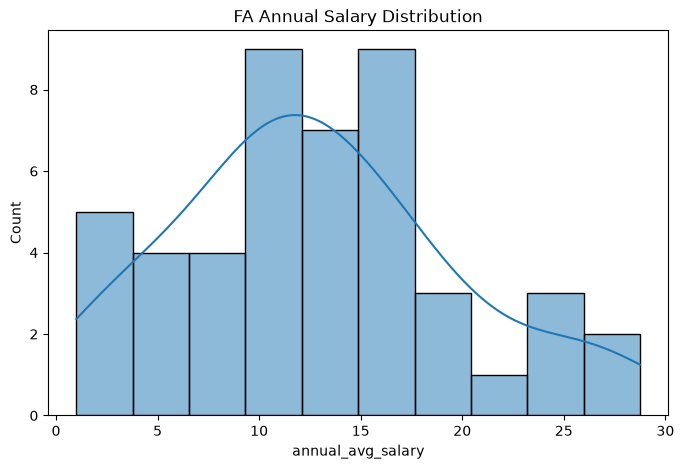

In [31]:
plt.figure(figsize=(8,5))

sns.histplot(
    hitter["annual_avg_salary"],
    bins=10,
    kde=True
)

plt.title("FA Annual Salary Distribution")

plt.show()

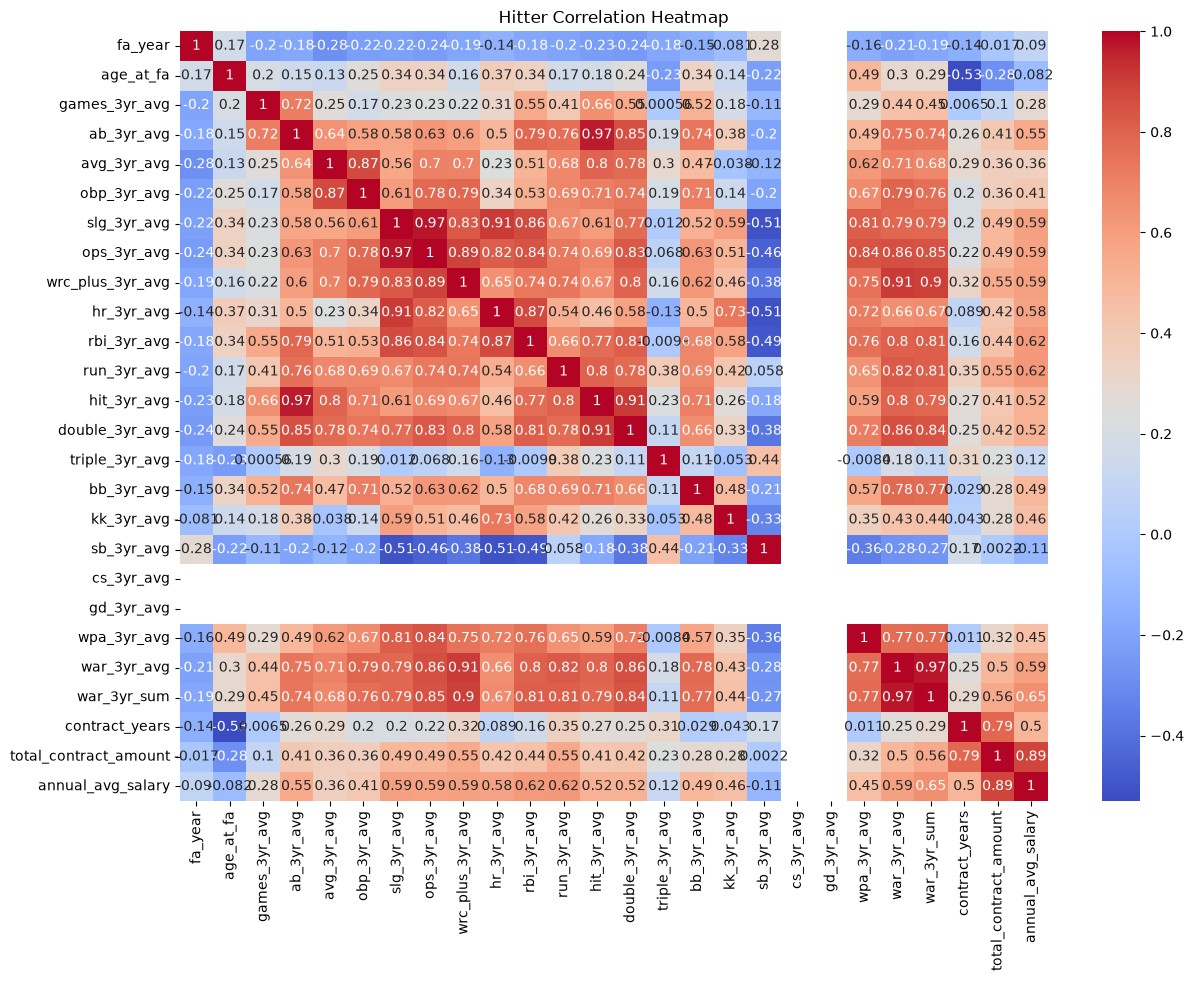

In [32]:
corr = hitter.corr(
    numeric_only=True
)

plt.figure(
    figsize=(14,10)
)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Hitter Correlation Heatmap"
)

plt.show()

In [33]:
corr_salary = corr[
    "annual_avg_salary"
].sort_values(
    ascending=False
)

print(corr_salary)

annual_avg_salary        1.000000
total_contract_amount    0.885838
war_3yr_sum              0.654899
run_3yr_avg              0.619709
rbi_3yr_avg              0.617161
wrc_plus_3yr_avg         0.592776
war_3yr_avg              0.588310
slg_3yr_avg              0.588108
ops_3yr_avg              0.585367
hr_3yr_avg               0.577368
ab_3yr_avg               0.549863
hit_3yr_avg              0.520101
double_3yr_avg           0.517434
contract_years           0.501636
bb_3yr_avg               0.487711
kk_3yr_avg               0.457068
wpa_3yr_avg              0.451105
obp_3yr_avg              0.405090
avg_3yr_avg              0.359217
games_3yr_avg            0.284115
triple_3yr_avg           0.124805
fa_year                  0.089655
age_at_fa               -0.082339
sb_3yr_avg              -0.108555
cs_3yr_avg                    NaN
gd_3yr_avg                    NaN
Name: annual_avg_salary, dtype: float64


In [34]:
import pandas as pd

hitter = pd.read_csv("../data/hitter_training_v3.csv")

print(hitter.shape)

display(hitter.head())

(47, 29)


,player_name,fa_year,age_at_fa,position,games_3yr_avg,ab_3yr_avg,avg_3yr_avg,obp_3yr_avg,slg_3yr_avg,ops_3yr_avg,...,sb_3yr_avg,cs_3yr_avg,gd_3yr_avg,wpa_3yr_avg,war_3yr_avg,war_3yr_sum,contract_years,total_contract_amount,annual_avg_salary,team
0,이대호,2021,39,1B,141.000000,523.333333,0.303127,0.367667,0.493333,0.861000,...,0.333333,NaN,NaN,1.127000,3.556667,10.67,2,26.0,13.00,롯데
1,김재호,2021,35,SS,127.000000,393.666667,0.289136,0.377000,0.394667,0.771667,...,5.000000,NaN,NaN,-0.487667,2.630000,7.89,3,25.0,8.33,두산
2,이원석,2021,34,3B,120.000000,425.666667,0.271395,0.347333,0.447000,0.794333,...,1.333333,NaN,NaN,0.501333,1.630000,4.89,3,20.0,6.67,삼성
3,정수빈,2021,29,OF,96.666667,343.000000,0.310204,0.383667,0.398667,0.782333,...,15.333333,NaN,NaN,-0.551000,2.260000,6.78,6,56.0,9.33,두산
4,최형우,2021,38,OF,139.666667,502.000000,0.331287,0.420000,0.541333,0.961333,...,1.000000,NaN,NaN,3.712667,5.796667,17.39,3,47.0,15.67,KIA


In [35]:
features = [
    "age_at_fa",

    "games_3yr_avg",
    "ab_3yr_avg",

    "avg_3yr_avg",
    "obp_3yr_avg",
    "slg_3yr_avg",
    "ops_3yr_avg",
    "wrc_plus_3yr_avg",

    "hr_3yr_avg",
    "rbi_3yr_avg",
    "run_3yr_avg",
    "hit_3yr_avg",

    "bb_3yr_avg",
    "kk_3yr_avg",

    "sb_3yr_avg",

    "wpa_3yr_avg",

    "war_3yr_avg",
    "war_3yr_sum"
]

target = "annual_avg_salary"

In [36]:
from sklearn.model_selection import train_test_split

X = hitter[features]
y = hitter[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(37, 18)
(10, 18)


In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import numpy as np

lr = LinearRegression()

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

r2 = r2_score(y_test, pred)

mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

print("R2:", r2)
print("RMSE:", rmse)

R2: 0.05661763869666514
RMSE: 6.150762463440284


In [39]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import numpy as np

In [40]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

print("Random Forest")
print("R2 :", rf_r2)
print("RMSE :", rf_rmse)

Random Forest
R2 : 0.27652247880708414
RMSE : 5.386387583512152


In [65]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(importance)

                feature  importance
2       innings_3yr_avg    0.166230
8          hold_3yr_avg    0.126018
3           era_3yr_avg    0.112519
11          war_3yr_sum    0.084780
10          war_3yr_avg    0.083215
9   hit_allowed_3yr_avg    0.064055
0             age_at_fa    0.063339
5           win_3yr_avg    0.060189
6          lose_3yr_avg    0.054836
1         games_3yr_avg    0.043960
13        era_last_year    0.036988
4          whip_3yr_avg    0.032801
14       whip_last_year    0.031869
12        war_last_year    0.030470
7          save_3yr_avg    0.008730


In [44]:
from xgboost import XGBRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import numpy as np

xgb = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.03,
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_pred
    )
)

print("XGBoost")
print("R2 :", xgb_r2)
print("RMSE :", xgb_rmse)


XGBoost
R2 : -0.16081462501671906
RMSE : 6.822860863508255


In [64]:
import pandas as pd
import numpy as np

hitter_raw = pd.read_csv("../data/naver_hitter_2015_2026_raw_all.csv")
pitcher_raw = pd.read_csv("../data/naver_pitcher_2015_2026_raw_all.csv")

print("타자 raw:", hitter_raw.shape)
print("투수 raw:", pitcher_raw.shape)

hitter_cols = [
    "collect_year", "playerId", "playerName", "teamName", "isRetire", "isPlayer",
    "hitterGameCount", "hitterAb",
    "hitterHra", "hitterObp", "hitterSlg", "hitterOps", "hitterWrcPlus",
    "hitterHr", "hitterRbi", "hitterRun", "hitterHit", "hitterH2", "hitterH3",
    "hitterBb", "hitterKk", "hitterSb", "hitterCs", "hitterGd",
    "hitterWpa", "hitterWar", "sort_source"
]

pitcher_cols = [
    "collect_year", "playerId", "playerName", "teamName", "isRetire", "isPlayer",
    "pitcherGameCount", "pitcherInning", "pitcherEra", "pitcherWhip",
    "pitcherWin", "pitcherLose", "pitcherSave", "pitcherHold",
    "pitcherHit", "pitcherWar", "sort_source"
]

hitter_cols = [c for c in hitter_cols if c in hitter_raw.columns]
pitcher_cols = [c for c in pitcher_cols if c in pitcher_raw.columns]

hitter_season = hitter_raw[hitter_cols].copy()
pitcher_season = pitcher_raw[pitcher_cols].copy()

hitter_season.to_csv(
    "../data/hitter_season_stats_2015_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

pitcher_season.to_csv(
    "../data/pitcher_season_stats_2015_2026.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료")
print("타자 season:", hitter_season.shape)
print("투수 season:", pitcher_season.shape)

타자 raw: (1390, 50)
투수 raw: (1940, 52)
저장 완료
타자 season: (1390, 27)
투수 season: (1940, 17)


In [46]:
import pandas as pd

hitter_raw = pd.read_csv("../data/naver_hitter_2015_2026_raw_all.csv")
pitcher_raw = pd.read_csv("../data/naver_pitcher_2015_2026_raw_all.csv")

hitter_cols_v2 = [
    "collect_year", "playerId", "playerName", "teamName",
    "isRetire", "isPlayer", "isQualified",

    "hitterGameCount", "hitterAb",

    "hitterHra", "hitterObp", "hitterSlg", "hitterOps",
    "hitterIsop", "hitterBabip", "hitterWoba", "hitterWrcPlus",

    "hitterHr", "hitterRbi", "hitterRun", "hitterHit",
    "hitterH2", "hitterH3",

    "hitterBb", "hitterHp", "hitterKk",

    "hitterSb", "hitterCs", "hitterGd",

    "hitterWpa", "hitterWar",

    "sort_source"
]

pitcher_cols_v2 = [
    "collect_year", "playerId", "playerName", "teamName",
    "isRetire", "isPlayer",

    "pitcherGameCount", "pitcherInning",
    "pitcherEra", "pitcherWhip",
    "pitcherWin", "pitcherLose",
    "pitcherSave", "pitcherHold",
    "pitcherHit",
    "pitcherWar",

    "sort_source"
]

hitter_cols_v2 = [c for c in hitter_cols_v2 if c in hitter_raw.columns]
pitcher_cols_v2 = [c for c in pitcher_cols_v2 if c in pitcher_raw.columns]

hitter_season_v2 = hitter_raw[hitter_cols_v2].copy()
pitcher_season_v2 = pitcher_raw[pitcher_cols_v2].copy()

hitter_season_v2.to_csv(
    "../data/hitter_season_stats_2015_2026_v2.csv",
    index=False,
    encoding="utf-8-sig"
)

pitcher_season_v2.to_csv(
    "../data/pitcher_season_stats_2015_2026_v2.csv",
    index=False,
    encoding="utf-8-sig"
)

print("타자 season v2:", hitter_season_v2.shape)
print("투수 season v2:", pitcher_season_v2.shape)
print("타자 컬럼:", hitter_season_v2.columns.tolist())
print("투수 컬럼:", pitcher_season_v2.columns.tolist())

타자 season v2: (1390, 32)
투수 season v2: (1940, 17)
타자 컬럼: ['collect_year', 'playerId', 'playerName', 'teamName', 'isRetire', 'isPlayer', 'isQualified', 'hitterGameCount', 'hitterAb', 'hitterHra', 'hitterObp', 'hitterSlg', 'hitterOps', 'hitterIsop', 'hitterBabip', 'hitterWoba', 'hitterWrcPlus', 'hitterHr', 'hitterRbi', 'hitterRun', 'hitterHit', 'hitterH2', 'hitterH3', 'hitterBb', 'hitterHp', 'hitterKk', 'hitterSb', 'hitterCs', 'hitterGd', 'hitterWpa', 'hitterWar', 'sort_source']
투수 컬럼: ['collect_year', 'playerId', 'playerName', 'teamName', 'isRetire', 'isPlayer', 'pitcherGameCount', 'pitcherInning', 'pitcherEra', 'pitcherWhip', 'pitcherWin', 'pitcherLose', 'pitcherSave', 'pitcherHold', 'pitcherHit', 'pitcherWar', 'sort_source']


In [47]:
import pandas as pd

fa = pd.read_csv("../data/fa_contracts_v3.csv")

print("FA 데이터:", fa.shape)
print("연도별 개수")
print(fa.groupby("fa_year").size())

print("\n포지션별 개수")
print(fa.groupby("position").size())

print("\n중복 확인")
print(fa[fa.duplicated(subset=["player_name", "fa_year"], keep=False)])

FA 데이터: (140, 9)
연도별 개수
fa_year
2018    19
2019    14
2020    18
2021    15
2022    14
2023    18
2024    14
2025    16
2026    12
dtype: int64

포지션별 개수
position
1B    10
2B     8
3B     8
C     16
IF     9
OF    32
P     47
SS    10
dtype: int64

중복 확인
Empty DataFrame
Columns: [player_name, fa_year, age_at_fa, position, contract_years, total_contract_amount, annual_avg_salary, team, birth_year]
Index: []


In [48]:
import pandas as pd
import numpy as np

# =========================
# 1. 데이터 불러오기
# =========================
hitter = pd.read_csv("../data/hitter_season_stats_2015_2026_v2.csv")
pitcher = pd.read_csv("../data/pitcher_season_stats_2015_2026_v2.csv")
fa = pd.read_csv("../data/fa_contracts_v3.csv")

fa["position_group"] = fa["position"].apply(lambda x: "pitcher" if x == "P" else "hitter")

print("타자 시즌:", hitter.shape)
print("투수 시즌:", pitcher.shape)
print("FA:", fa.shape)
print(fa["position_group"].value_counts())


# =========================
# 2. 숫자 변환 함수
# =========================
def convert_inning(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()

    if " " in value:
        whole, fraction = value.split(" ")
        numerator, denominator = fraction.split("/")
        return float(whole) + float(numerator) / float(denominator)

    if "/" in value:
        numerator, denominator = value.split("/")
        return float(numerator) / float(denominator)

    return float(value)


# =========================
# 3. 타자 v4 생성
# =========================
hitter_numeric_cols = [
    "hitterGameCount", "hitterAb",
    "hitterHra", "hitterObp", "hitterSlg", "hitterOps",
    "hitterIsop", "hitterBabip", "hitterWoba", "hitterWrcPlus",
    "hitterHr", "hitterRbi", "hitterRun", "hitterHit",
    "hitterH2", "hitterH3",
    "hitterBb", "hitterHp", "hitterKk",
    "hitterSb", "hitterCs", "hitterGd",
    "hitterWpa", "hitterWar"
]

for col in hitter_numeric_cols:
    if col in hitter.columns:
        hitter[col] = pd.to_numeric(hitter[col], errors="coerce")

fa_hitter = fa[fa["position_group"] == "hitter"].copy()
hitter_rows = []

for _, row in fa_hitter.iterrows():
    player = row["player_name"]
    fa_year = int(row["fa_year"])
    target_years = [fa_year - 3, fa_year - 2, fa_year - 1]

    stats = hitter[
        (hitter["playerName"] == player) &
        (hitter["collect_year"].isin(target_years))
    ]

    if len(stats) < 2:
        continue

    result = {
        "player_name": player,
        "fa_year": fa_year,
        "age_at_fa": row["age_at_fa"],
        "position": row["position"],

        "games_3yr_avg": stats["hitterGameCount"].mean(),
        "ab_3yr_avg": stats["hitterAb"].mean(),

        "avg_3yr_avg": stats["hitterHra"].mean(),
        "obp_3yr_avg": stats["hitterObp"].mean(),
        "slg_3yr_avg": stats["hitterSlg"].mean(),
        "ops_3yr_avg": stats["hitterOps"].mean(),
        "isop_3yr_avg": stats["hitterIsop"].mean(),
        "babip_3yr_avg": stats["hitterBabip"].mean(),
        "woba_3yr_avg": stats["hitterWoba"].mean(),
        "wrc_plus_3yr_avg": stats["hitterWrcPlus"].mean(),

        "hr_3yr_avg": stats["hitterHr"].mean(),
        "rbi_3yr_avg": stats["hitterRbi"].mean(),
        "run_3yr_avg": stats["hitterRun"].mean(),
        "hit_3yr_avg": stats["hitterHit"].mean(),
        "double_3yr_avg": stats["hitterH2"].mean(),
        "triple_3yr_avg": stats["hitterH3"].mean(),

        "bb_3yr_avg": stats["hitterBb"].mean(),
        "hp_3yr_avg": stats["hitterHp"].mean(),
        "kk_3yr_avg": stats["hitterKk"].mean(),

        "sb_3yr_avg": stats["hitterSb"].mean(),
        "cs_3yr_avg": stats["hitterCs"].mean(),
        "gd_3yr_avg": stats["hitterGd"].mean(),

        "wpa_3yr_avg": stats["hitterWpa"].mean(),
        "war_3yr_avg": stats["hitterWar"].mean(),
        "war_3yr_sum": stats["hitterWar"].sum(),

        # 최근 시즌 가중 변수
        "war_last_year": stats[stats["collect_year"] == fa_year - 1]["hitterWar"].mean(),
        "ops_last_year": stats[stats["collect_year"] == fa_year - 1]["hitterOps"].mean(),
        "wrc_plus_last_year": stats[stats["collect_year"] == fa_year - 1]["hitterWrcPlus"].mean(),

        "contract_years": row["contract_years"],
        "total_contract_amount": row["total_contract_amount"],
        "annual_avg_salary": row["annual_avg_salary"],
        "team": row["team"]
    }

    hitter_rows.append(result)

hitter_training_v4 = pd.DataFrame(hitter_rows)

hitter_training_v4.to_csv(
    "../data/hitter_training_v4.csv",
    index=False,
    encoding="utf-8-sig"
)

print("타자 training v4:", hitter_training_v4.shape)


# =========================
# 4. 투수 v4 생성
# =========================
pitcher_feature_map = {
    "pitcherGameCount": "games_3yr_avg",
    "pitcherInning": "innings_3yr_avg",
    "pitcherEra": "era_3yr_avg",
    "pitcherWhip": "whip_3yr_avg",
    "pitcherWin": "win_3yr_avg",
    "pitcherLose": "lose_3yr_avg",
    "pitcherSave": "save_3yr_avg",
    "pitcherHold": "hold_3yr_avg",
    "pitcherHit": "hit_allowed_3yr_avg",
    "pitcherWar": "war_3yr_avg"
}

for col in pitcher_feature_map.keys():
    if col in pitcher.columns:
        if col == "pitcherInning":
            pitcher[col] = pitcher[col].apply(convert_inning)
        else:
            pitcher[col] = pd.to_numeric(pitcher[col], errors="coerce")

fa_pitcher = fa[fa["position_group"] == "pitcher"].copy()
pitcher_rows = []

for _, row in fa_pitcher.iterrows():
    player = row["player_name"]
    fa_year = int(row["fa_year"])
    target_years = [fa_year - 3, fa_year - 2, fa_year - 1]

    stats = pitcher[
        (pitcher["playerName"] == player) &
        (pitcher["collect_year"].isin(target_years))
    ]

    if len(stats) < 2:
        continue

    result = {
        "player_name": player,
        "fa_year": fa_year,
        "age_at_fa": row["age_at_fa"],
        "position": row["position"],

        "contract_years": row["contract_years"],
        "total_contract_amount": row["total_contract_amount"],
        "annual_avg_salary": row["annual_avg_salary"],
        "team": row["team"]
    }

    for raw_col, new_col in pitcher_feature_map.items():
        result[new_col] = stats[raw_col].mean()

    result["war_3yr_sum"] = stats["pitcherWar"].sum()

    # 최근 시즌 가중 변수
    last_stats = stats[stats["collect_year"] == fa_year - 1]
    result["war_last_year"] = last_stats["pitcherWar"].mean()
    result["era_last_year"] = last_stats["pitcherEra"].mean()
    result["whip_last_year"] = last_stats["pitcherWhip"].mean()

    pitcher_rows.append(result)

pitcher_training_v4 = pd.DataFrame(pitcher_rows)

pitcher_training_v4.to_csv(
    "../data/pitcher_training_v4.csv",
    index=False,
    encoding="utf-8-sig"
)

print("투수 training v4:", pitcher_training_v4.shape)


# =========================
# 5. 결측치 확인
# =========================
print("\n타자 결측치")
print(hitter_training_v4.isnull().sum())

print("\n투수 결측치")
print(pitcher_training_v4.isnull().sum())

타자 시즌: (1390, 32)
투수 시즌: (1940, 17)
FA: (140, 10)
position_group
hitter     93
pitcher    47
Name: count, dtype: int64
타자 training v4: (80, 36)
투수 training v4: (43, 22)

타자 결측치
player_name               0
fa_year                   0
age_at_fa                 0
position                  0
games_3yr_avg             0
ab_3yr_avg                0
avg_3yr_avg               0
obp_3yr_avg               0
slg_3yr_avg               0
ops_3yr_avg               0
isop_3yr_avg              0
babip_3yr_avg             0
woba_3yr_avg              0
wrc_plus_3yr_avg          0
hr_3yr_avg                0
rbi_3yr_avg               0
run_3yr_avg               0
hit_3yr_avg               0
double_3yr_avg            0
triple_3yr_avg            0
bb_3yr_avg                0
hp_3yr_avg                0
kk_3yr_avg                0
sb_3yr_avg                0
cs_3yr_avg               80
gd_3yr_avg               80
wpa_3yr_avg               0
war_3yr_avg               0
war_3yr_sum               0
war_last_ye

In [49]:
import pandas as pd
import numpy as np

hitter = pd.read_csv("../data/hitter_training_v4.csv")

hitter_features = [
    "age_at_fa",
    "games_3yr_avg", "ab_3yr_avg",
    "avg_3yr_avg", "obp_3yr_avg", "slg_3yr_avg", "ops_3yr_avg",
    "isop_3yr_avg", "babip_3yr_avg", "woba_3yr_avg", "wrc_plus_3yr_avg",
    "hr_3yr_avg", "rbi_3yr_avg", "run_3yr_avg", "hit_3yr_avg",
    "double_3yr_avg", "triple_3yr_avg",
    "bb_3yr_avg", "hp_3yr_avg", "kk_3yr_avg",
    "sb_3yr_avg", "cs_3yr_avg", "gd_3yr_avg",
    "wpa_3yr_avg", "war_3yr_avg", "war_3yr_sum",
    "war_last_year", "ops_last_year", "wrc_plus_last_year"
]

target = "annual_avg_salary"

hitter_model_df = hitter[hitter_features + [target]].copy()

for col in hitter_model_df.columns:
    hitter_model_df[col] = pd.to_numeric(hitter_model_df[col], errors="coerce")

print("결측치 확인")
print(hitter_model_df.isnull().sum())

hitter_model_df = hitter_model_df.dropna()

print("타자 모델 데이터:", hitter_model_df.shape)

결측치 확인
age_at_fa              0
games_3yr_avg          0
ab_3yr_avg             0
avg_3yr_avg            0
obp_3yr_avg            0
slg_3yr_avg            0
ops_3yr_avg            0
isop_3yr_avg           0
babip_3yr_avg          0
woba_3yr_avg           0
wrc_plus_3yr_avg       0
hr_3yr_avg             0
rbi_3yr_avg            0
run_3yr_avg            0
hit_3yr_avg            0
double_3yr_avg         0
triple_3yr_avg         0
bb_3yr_avg             0
hp_3yr_avg             0
kk_3yr_avg             0
sb_3yr_avg             0
cs_3yr_avg            80
gd_3yr_avg            80
wpa_3yr_avg            0
war_3yr_avg            0
war_3yr_sum            0
war_last_year          5
ops_last_year          5
wrc_plus_last_year     5
annual_avg_salary      0
dtype: int64
타자 모델 데이터: (0, 30)


In [53]:
# 전부 NaN인 컬럼 제거
hitter_model_df = hitter_model_df.dropna(axis=1, how="all")

# target은 유지 확인
target = "annual_avg_salary"

# feature 목록 다시 만들기
hitter_features_clean = [
    col for col in hitter_model_df.columns
    if col != target
]

# 남은 결측치는 중앙값으로 채우기
for col in hitter_features_clean:
    hitter_model_df[col] = hitter_model_df[col].fillna(
        hitter_model_df[col].median()
    )

print("타자 모델 데이터:", hitter_model_df.shape)
print("남은 결측치:", hitter_model_df.isnull().sum().sum())
print("최종 사용 피처 수:", len(hitter_features_clean))
print(hitter_features_clean)

타자 모델 데이터: (80, 28)
남은 결측치: 0
최종 사용 피처 수: 27
['age_at_fa', 'games_3yr_avg', 'ab_3yr_avg', 'avg_3yr_avg', 'obp_3yr_avg', 'slg_3yr_avg', 'ops_3yr_avg', 'isop_3yr_avg', 'babip_3yr_avg', 'woba_3yr_avg', 'wrc_plus_3yr_avg', 'hr_3yr_avg', 'rbi_3yr_avg', 'run_3yr_avg', 'hit_3yr_avg', 'double_3yr_avg', 'triple_3yr_avg', 'bb_3yr_avg', 'hp_3yr_avg', 'kk_3yr_avg', 'sb_3yr_avg', 'wpa_3yr_avg', 'war_3yr_avg', 'war_3yr_sum', 'war_last_year', 'ops_last_year', 'wrc_plus_last_year']


In [54]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import numpy as np
import pandas as pd

target = "annual_avg_salary"

X = hitter_model_df[hitter_features_clean]
y = hitter_model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(64, 27)
(16, 27)


In [55]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear")
print("R2 :", lr_r2)
print("MSE :", lr_mse)
print("RMSE :", lr_rmse)

Linear
R2 : 0.3182202877846968
MSE : 39.93852318043302
RMSE : 6.319693282148512


In [56]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("R2 :", rf_r2)
print("MSE :", rf_mse)
print("RMSE :", rf_rmse)

Random Forest
R2 : 0.3749031288214839
MSE : 36.61805335694022
RMSE : 6.051285264878877


In [2]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(
    importance["feature"][::-1],
    importance["importance"][::-1],
    color="steelblue",
    edgecolor="white"
)
ax.set_xlabel("Feature Importance", fontsize=12)
ax.set_title("Hitter - Random Forest Feature Importance", fontsize=14, fontweight="bold")
ax.axvline(x=importance["importance"].mean(), color="tomato", linestyle="--", linewidth=1.2, label=f"mean ({importance['importance'].mean():.3f})")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

display(importance)

NameError: name 'pd' is not defined

In [57]:
import pandas as pd
import numpy as np

pitcher = pd.read_csv("../data/pitcher_training_v4.csv")

pitcher_features = [
    "age_at_fa",

    "games_3yr_avg",
    "innings_3yr_avg",

    "era_3yr_avg",
    "whip_3yr_avg",

    "win_3yr_avg",
    "lose_3yr_avg",

    "save_3yr_avg",
    "hold_3yr_avg",

    "hit_allowed_3yr_avg",

    "war_3yr_avg",
    "war_3yr_sum",

    "war_last_year",
    "era_last_year",
    "whip_last_year"
]

target = "annual_avg_salary"

pitcher_model_df = pitcher[pitcher_features + [target]].copy()

for col in pitcher_model_df.columns:
    pitcher_model_df[col] = pd.to_numeric(
        pitcher_model_df[col],
        errors="coerce"
    )

# 최근 시즌 결측치 보정
pitcher_model_df["war_last_year"] = pitcher_model_df["war_last_year"].fillna(
    pitcher_model_df["war_3yr_avg"]
)

pitcher_model_df["era_last_year"] = pitcher_model_df["era_last_year"].fillna(
    pitcher_model_df["era_3yr_avg"]
)

pitcher_model_df["whip_last_year"] = pitcher_model_df["whip_last_year"].fillna(
    pitcher_model_df["whip_3yr_avg"]
)

# 나머지 중앙값 대체
for col in pitcher_model_df.columns:
    pitcher_model_df[col] = pitcher_model_df[col].fillna(
        pitcher_model_df[col].median()
    )

print("투수 모델 데이터:", pitcher_model_df.shape)
print("남은 결측치:", pitcher_model_df.isnull().sum().sum())

투수 모델 데이터: (43, 16)
남은 결측치: 0


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import numpy as np

X = pitcher_model_df[pitcher_features]
y = pitcher_model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear")
print("R2 :", lr_r2)
print("MSE :", lr_mse)
print("RMSE :", lr_rmse)

Linear
R2 : 0.7104408571673586
MSE : 12.865720432773779
RMSE : 3.5868817143549325


In [59]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("R2 :", rf_r2)
print("MSE :", rf_mse)
print("RMSE :", rf_rmse)

Random Forest
R2 : 0.43239547606523143
MSE : 25.219860267175704
RMSE : 5.0219378995738


In [62]:
model_summary = pd.DataFrame({
    "group": ["Hitter", "Hitter", "Pitcher", "Pitcher"],
    "model": ["Linear", "RandomForest", "Linear", "RandomForest"],
    "R2": [
        0.318,
        0.375,
        0.710,
        0.432
    ],
    "RMSE": [
        6.32,
        6.05,
        3.59,
        5.02
    ]
})

display(model_summary)

,group,model,R2,RMSE
0,Hitter,Linear,0.318,6.32
1,Hitter,RandomForest,0.375,6.05
2,Pitcher,Linear,0.710,3.59
3,Pitcher,RandomForest,0.432,5.02


In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error

# 데이터 불러오기
hitter_model_df = pd.read_csv(
    "../data/hitter_training_v4.csv"
)

target = "annual_avg_salary"

# 사용 안할 컬럼 제거
drop_cols = [
    "player_name",
    "position",
    "team",
    target
]

feature_cols = [
    col
    for col in hitter_model_df.columns
    if col not in drop_cols
]

# 숫자형 변환
for col in feature_cols + [target]:
    hitter_model_df[col] = pd.to_numeric(
        hitter_model_df[col],
        errors="coerce"
    )

# 최근 시즌 결측치 처리
hitter_model_df["war_last_year"] = hitter_model_df["war_last_year"].fillna(
    hitter_model_df["war_3yr_avg"]
)

hitter_model_df["ops_last_year"] = hitter_model_df["ops_last_year"].fillna(
    hitter_model_df["ops_3yr_avg"]
)

hitter_model_df["wrc_plus_last_year"] = hitter_model_df["wrc_plus_last_year"].fillna(
    hitter_model_df["wrc_plus_3yr_avg"]
)

# 전부 NaN 컬럼 제거
hitter_model_df = hitter_model_df.dropna(
    axis=1,
    how="all"
)

# 남은 결측치 중앙값 처리
for col in hitter_model_df.columns:
    if hitter_model_df[col].isnull().sum() > 0:
        hitter_model_df[col] = hitter_model_df[col].fillna(
            hitter_model_df[col].median()
        )

feature_cols = [
    col
    for col in hitter_model_df.columns
    if col not in drop_cols
]

X = hitter_model_df[feature_cols]
y = hitter_model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

rf_hitter = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf_hitter.fit(X_train, y_train)

pred = rf_hitter.predict(X_test)

print("R2 :", r2_score(y_test, pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))

importance_hitter = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_hitter.feature_importances_
})

importance_hitter = importance_hitter.sort_values(
    by="importance",
    ascending=False
)

print("\n=== HITTER FEATURE IMPORTANCE ===")
print(importance_hitter)

R2 : 0.8610976900191645
RMSE : 2.852520000297294

=== HITTER FEATURE IMPORTANCE ===
                  feature  importance
29  total_contract_amount    0.812502
13            rbi_3yr_avg    0.015844
6             slg_3yr_avg    0.014251
26          ops_last_year    0.013573
12             hr_3yr_avg    0.010551
8            isop_3yr_avg    0.010084
25          war_last_year    0.009530
16         double_3yr_avg    0.009415
27     wrc_plus_last_year    0.009148
11       wrc_plus_3yr_avg    0.008657
20             kk_3yr_avg    0.007316
7             ops_3yr_avg    0.007291
24            war_3yr_sum    0.006659
2           games_3yr_avg    0.006464
1               age_at_fa    0.006302
19             hp_3yr_avg    0.006009
3              ab_3yr_avg    0.005280
18             bb_3yr_avg    0.004251
0                 fa_year    0.003965
14            run_3yr_avg    0.003945
10           woba_3yr_avg    0.003742
21             sb_3yr_avg    0.003566
23            war_3yr_avg    0.003429
4   